In [ ]:
# CELL 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')


import os
PROJECT_DIR = '/content/drive/MyDrive/MusicGenerationCSE425'
os.makedirs(PROJECT_DIR, exist_ok=True)
print(f"Project directory: {PROJECT_DIR}")

Mounted at /content/drive
Project directory: /content/drive/MyDrive/MusicGenerationCSE425


In [ ]:
#CELL 1: Setup (same as before)
!pip install pretty_midi -q
from google.colab import drive
drive.mount('/content/drive')
import os, numpy as np, torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

PROJECT_DIR = '/content/drive/MyDrive/MusicGenerationCSE425'
PROCESSED_DIR = f'{PROJECT_DIR}/data/processed'
MODELS_DIR = f'{PROJECT_DIR}/models_saved'
MIDI_OUT_DIR = f'{PROJECT_DIR}/outputs/generated_midis'
PLOTS_DIR = f'{PROJECT_DIR}/outputs/plots'
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 129.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 6.1 MB/s eta 0:00:00
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cuda


In [ ]:
#CELL 2: Dataset & DataLoaders
class PianoRollDataset(torch.utils.data.Dataset):
    def __init__(self, npy_path):
        self.data = np.load(npy_path)
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        return torch.tensor(self.data[idx], dtype=torch.float32)

BATCH_SIZE = 64
train_loader = DataLoader(PianoRollDataset(f"{PROCESSED_DIR}/piano_roll_train.npy"), batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(PianoRollDataset(f"{PROCESSED_DIR}/piano_roll_validation.npy"), batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
print("DataLoaders ready")

DataLoaders ready


In [ ]:
#CELL 3: VAE Architecture

class VAEEncoder(nn.Module):
    """
    VAE Encoder: outputs mean (mu) and log-variance (log_var) that define the posterior distribution q(z|X) = N(mu, sigma^2).
    Input: (batch, T, 88)
    Output: mu (batch, latent_dim), log_var (batch, latent_dim)
    """
    def __init__(self, input_dim=88, hidden_dim=256, latent_dim=64, num_layers=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout if num_layers > 1 else 0.0)
        #Separate linear heads for mu and log_var
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_log_var = nn.Linear(hidden_dim, latent_dim)

    def forward(self, x):
        _, (h_n, _) = self.lstm(x)
        last_hidden = h_n[-1]
        mu = self.fc_mu(last_hidden)
        log_var = self.fc_log_var(last_hidden)
        return mu, log_var


class VAEDecoder(nn.Module):
    """
    Same as Task 1 Decoder - reconstructs piano-roll from latent z.
    Input:  (batch, latent_dim)
    Output: (batch, T, 88) - raw logits
    """
    def __init__(self, latent_dim=64, hidden_dim=256, output_dim=88, seq_len=128, num_layers=2, dropout=0.3):
        super().__init__()
        self.seq_len = seq_len
        self.fc_in = nn.Linear(latent_dim, hidden_dim)
        self.lstm = nn.LSTM(latent_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout if num_layers > 1 else 0.0)
        self.fc_out = nn.Linear(hidden_dim, output_dim)

    def forward(self, z):
        z_repeated = z.unsqueeze(1).repeat(1, self.seq_len, 1)
        h0 = self.fc_in(z).unsqueeze(0).repeat(2, 1, 1)
        c0 = torch.zeros_like(h0)
        out, _ = self.lstm(z_repeated, (h0, c0))
        return self.fc_out(out)
class MusicVAE(nn.Module):
    """
    Variational Autoencoder for music generation.
    Implements the full ELBO:
      L_VAE = L_recon + beta * KL(q(z|X) || p(z))
    Reparameterization trick:
      z = mu + sigma * eps,  eps ~ N(0, I)
    """
    def __init__(self, input_dim=88, hidden_dim=256, latent_dim=64, seq_len=128, num_layers=2, dropout=0.3):
        super().__init__()
        self.encoder = VAEEncoder(input_dim, hidden_dim, latent_dim, num_layers, dropout)
        self.decoder = VAEDecoder(latent_dim, hidden_dim, input_dim, seq_len, num_layers, dropout)
        self.latent_dim = latent_dim

    def reparameterize(self, mu, log_var):

        sigma = torch.exp(0.5 * log_var)
        eps   = torch.randn_like(sigma)
        return mu + sigma * eps

    def forward(self, x):
        mu, log_var = self.encoder(x)
        z    = self.reparameterize(mu, log_var)
        x_hat = self.decoder(z)
        return x_hat, mu, log_var

vae = MusicVAE(input_dim=88, hidden_dim=256, latent_dim=64, seq_len=128).to(DEVICE)
total_params = sum(p.numel() for p in vae.parameters() if p.requires_grad)
print(f"MusicVAE ready - Trainable parameters: {total_params:,}")

MusicVAE ready - Trainable parameters: 1,808,856


In [ ]:
#CELL 4: VAE Loss with KL Annealing
#KL annealing prevents posterior collapse by starting with
#beta=0 (pure reconstruction) and increasing beta gradually

class FocalLoss(nn.Module):
    """Focal loss (same as Task 1) for reconstruction term."""
    def __init__(self, alpha=10.0, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        bce = nn.functional.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        pt = torch.where(targets == 1, probs, 1 - probs)
        focal_weight = (1 - pt) ** self.gamma
        alpha_weight = torch.where(targets == 1, torch.tensor(self.alpha, device=logits.device), torch.tensor(1.0, device=logits.device))
        return (alpha_weight * focal_weight * bce).mean()

def kl_divergence(mu, log_var):
    """
    Closed-form KL divergence between N(mu, sigma^2) and N(0, I).
    KL = -0.5 * sum(1 + log_var - mu^2 - exp(log_var))
    """
    return -0.5 * torch.mean(1 + log_var - mu.pow(2) - log_var.exp())

def get_beta(epoch, warmup_epochs=30, max_beta=1.0):
    #KL annealing schedule: beta linearly increases from 0 to max_beta over the first warmup_epochs epochs, then stays at max_beta. This prevents posterior collapse.

    return min(max_beta, (epoch / warmup_epochs) * max_beta)

focal_loss = FocalLoss(alpha=10.0, gamma=2.0)
print("VAE Loss functions ready (with KL annealing)")

VAE Loss functions ready (with KL annealing)


In [ ]:
#CELL 5: VAE Training Loop
EPOCHS = 100
LR = 1e-3
CLIP_NORM = 1.0
WARMUP = 30   #epochs before KL term reaches full weight

optimizer = torch.optim.Adam(vae.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)

train_recon_losses = []
train_kl_losses = []
val_losses = []
best_val_loss = float('inf')

print(f"Training MusicVAE for {EPOCHS} epochs (KL warmup: {WARMUP} epochs)...\n")

for epoch in range(1, EPOCHS + 1):
    beta = get_beta(epoch, warmup_epochs=WARMUP)

    #Training phase
    vae.train()
    total_recon = 0.0
    total_kl = 0.0

    for batch in train_loader:
        batch = batch.to(DEVICE)
        optimizer.zero_grad()

        x_hat, mu, log_var = vae(batch)

        loss_recon = focal_loss(x_hat, batch)
        loss_kl = kl_divergence(mu, log_var)
        loss_total = loss_recon + beta * loss_kl

        loss_total.backward()
        torch.nn.utils.clip_grad_norm_(vae.parameters(), CLIP_NORM)
        optimizer.step()

        total_recon += loss_recon.item()
        total_kl += loss_kl.item()

    avg_recon = total_recon / len(train_loader)
    avg_kl = total_kl / len(train_loader)

    #Validation phase
    vae.eval()
    total_val = 0.0
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(DEVICE)
            x_hat, mu, log_var = vae(batch)
            loss_recon = focal_loss(x_hat, batch)
            loss_kl    = kl_divergence(mu, log_var)
            total_val += (loss_recon + beta * loss_kl).item()

    avg_val = total_val / len(val_loader)
    scheduler.step(avg_val)

    train_recon_losses.append(avg_recon)
    train_kl_losses.append(avg_kl)
    val_losses.append(avg_val)

    if avg_val < best_val_loss:
        best_val_loss = avg_val
        torch.save(vae.state_dict(), f"{MODELS_DIR}/task2_vae_best.pth")

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{EPOCHS} | beta={beta:.2f} | "
              f"Recon: {avg_recon:.4f} | KL: {avg_kl:.4f} | Val: {avg_val:.4f}")

print(f"\nVAE Training complete! Best Val Loss: {best_val_loss:.4f}")

Training MusicVAE for 100 epochs (KL warmup: 30 epochs)...

Epoch   1/100 | beta=0.03 | Recon: 0.2027 | KL: 0.0544 | Val: 0.1936
Epoch  10/100 | beta=0.33 | Recon: 0.1678 | KL: 0.0588 | Val: 0.1859
Epoch  20/100 | beta=0.67 | Recon: 0.1785 | KL: 0.0315 | Val: 0.1976
Epoch  30/100 | beta=1.00 | Recon: 0.1906 | KL: 0.0162 | Val: 0.2038
Epoch  40/100 | beta=1.00 | Recon: 0.1906 | KL: 0.0159 | Val: 0.2037
Epoch  50/100 | beta=1.00 | Recon: 0.1904 | KL: 0.0159 | Val: 0.2035
Epoch  60/100 | beta=1.00 | Recon: 0.1902 | KL: 0.0161 | Val: 0.2035
Epoch  70/100 | beta=1.00 | Recon: 0.1902 | KL: 0.0160 | Val: 0.2035
Epoch  80/100 | beta=1.00 | Recon: 0.1901 | KL: 0.0161 | Val: 0.2035
Epoch  90/100 | beta=1.00 | Recon: 0.1901 | KL: 0.0160 | Val: 0.2035
Epoch 100/100 | beta=1.00 | Recon: 0.1901 | KL: 0.0161 | Val: 0.2037

VAE Training complete! Best Val Loss: 0.1763


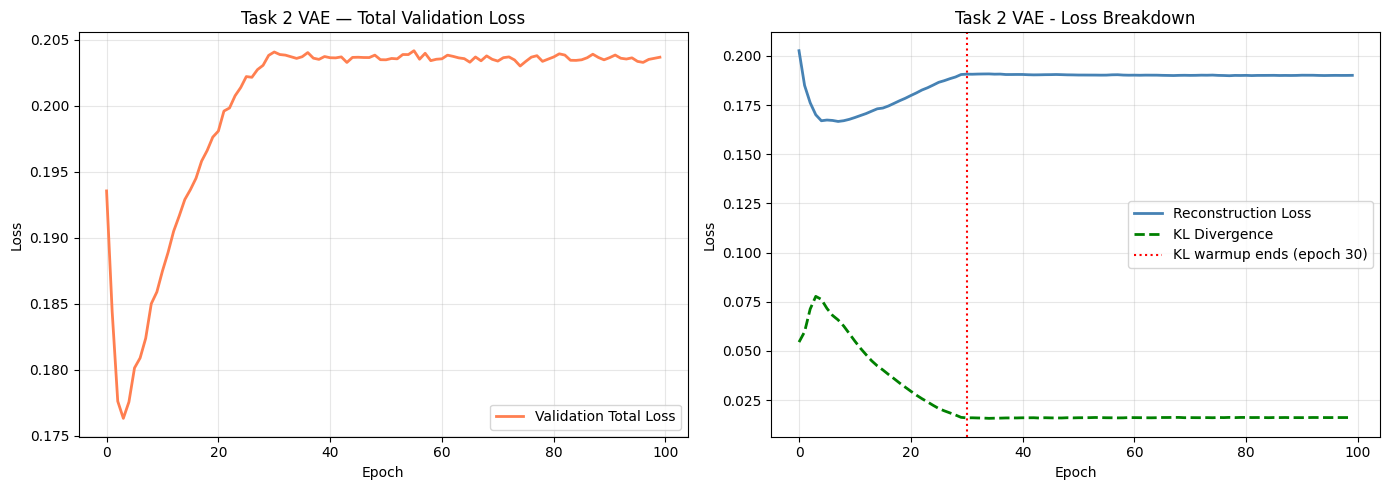

VAE loss curves saved!


In [ ]:
#CELL 6: Plot VAE Training Curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

#Total loss comparison
ax1.plot(val_losses, label='Validation Total Loss', color='coral', linewidth=2)
ax1.set_title('Task 2 VAE — Total Validation Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(alpha=0.3)

#KL vs Reconstruction breakdown
ax2.plot(train_recon_losses, label = 'Reconstruction Loss', color='steelblue', linewidth=2)
ax2.plot(train_kl_losses, label='KL Divergence', color='green', linewidth=2, linestyle='--')
ax2.axvline(30, color='red', linestyle=':', label='KL warmup ends (epoch 30)')
ax2.set_title('Task 2 VAE - Loss Breakdown')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/task2_vae_loss.png", dpi=150)
plt.show()
print("VAE loss curves saved!")

In [ ]:
#CELL 7: Generate 8 Multi-Genre Samples
#Multi-genre" here = different regions of the latent space
import pretty_midi

def piano_roll_to_midi(piano_roll_binary, frame_rate=16, velocity=80, piano_min=21):
    """Convert binary (T, 88) piano-roll array to PrettyMIDI object."""
    midi  = pretty_midi.PrettyMIDI()
    piano = pretty_midi.Instrument(program=0)
    T, n_pitches = piano_roll_binary.shape
    frame_dur = 1.0 / frame_rate

    for pitch_idx in range(n_pitches):
        pitch = pitch_idx + piano_min
        active = False
        note_start = 0.0
        for t in range(T):
            if piano_roll_binary[t, pitch_idx] == 1 and not active:
                note_start = t * frame_dur
                active = True
            elif piano_roll_binary[t, pitch_idx] == 0 and active:
                note_end = t * frame_dur
                if note_end - note_start >= frame_dur:
                    piano.notes.append(pretty_midi.Note(velocity=velocity, pitch=pitch, start=note_start, end=note_end))
                active = False
        if active:
            piano.notes.append(pretty_midi.Note(
                velocity=velocity, pitch=pitch,
                start=note_start, end=T * frame_dur))

    midi.instruments.append(piano)
    return midi


vae.load_state_dict(torch.load(f"{MODELS_DIR}/task2_vae_best.pth"))
vae.eval()

print("Generating 8 VAE multi-genre samples")
with torch.no_grad():
    for i in range(8):
        z = torch.randn(1, vae.latent_dim).to(DEVICE)
        logits = vae.decoder(z)
        probs = torch.sigmoid(logits).squeeze(0).cpu().numpy()
        binary = (probs > 0.3).astype(np.float32)

        midi_obj = piano_roll_to_midi(binary)
        out_path = f"{MIDI_OUT_DIR}/task2_vae_sample_{i+1}.mid"
        midi_obj.write(out_path)
        n_notes = sum(len(inst.notes) for inst in midi_obj.instruments)
        print(f"Sample {i+1}: {n_notes} notes in {out_path}")

print("Task 2 generation complete!")

Generating 8 VAE multi-genre samples
Sample 1: 44 notes in /content/drive/MyDrive/MusicGenerationCSE425/outputs/generated_midis/task2_vae_sample_1.mid
Sample 2: 54 notes in /content/drive/MyDrive/MusicGenerationCSE425/outputs/generated_midis/task2_vae_sample_2.mid
Sample 3: 43 notes in /content/drive/MyDrive/MusicGenerationCSE425/outputs/generated_midis/task2_vae_sample_3.mid
Sample 4: 45 notes in /content/drive/MyDrive/MusicGenerationCSE425/outputs/generated_midis/task2_vae_sample_4.mid
Sample 5: 38 notes in /content/drive/MyDrive/MusicGenerationCSE425/outputs/generated_midis/task2_vae_sample_5.mid
Sample 6: 54 notes in /content/drive/MyDrive/MusicGenerationCSE425/outputs/generated_midis/task2_vae_sample_6.mid
Sample 7: 52 notes in /content/drive/MyDrive/MusicGenerationCSE425/outputs/generated_midis/task2_vae_sample_7.mid
Sample 8: 48 notes in /content/drive/MyDrive/MusicGenerationCSE425/outputs/generated_midis/task2_vae_sample_8.mid
Task 2 generation complete!


In [ ]:
#CELL 8: Latent Interpolation Experiment (Required Deliverable)
#Smoothly morph between two real music pieces through latent space

#Load two real training examples
train_data = np.load(f"{PROCESSED_DIR}/piano_roll_train.npy")
sample_A = torch.tensor(train_data[0:1], dtype=torch.float32).to(DEVICE)
sample_B = torch.tensor(train_data[200:201], dtype=torch.float32).to(DEVICE)

vae.eval()
with torch.no_grad():
    mu_A, _ = vae.encoder(sample_A)
    mu_B, _ = vae.encoder(sample_B)

    print("Generating 8 interpolated samples between piece A and piece B")
    alphas = np.linspace(0, 1, 8)

    for i, alpha in enumerate(alphas):
        #Spherical interpolation between two latent codes
        z_interp = (1 - alpha) * mu_A + alpha * mu_B

        logits = vae.decoder(z_interp)
        probs  = torch.sigmoid(logits).squeeze(0).cpu().numpy()
        binary = (probs > 0.3).astype(np.float32)

        midi_obj = piano_roll_to_midi(binary)
        out_path = f"{MIDI_OUT_DIR}/task2_interpolation_alpha{alpha:.2f}.mid"
        midi_obj.write(out_path)
        print(f"alpha={alpha:.2f} in {out_path}")

print("Latent interpolation complete!")

Generating 8 interpolated samples between piece A and piece B
alpha=0.00 in /content/drive/MyDrive/MusicGenerationCSE425/outputs/generated_midis/task2_interpolation_alpha0.00.mid
alpha=0.14 in /content/drive/MyDrive/MusicGenerationCSE425/outputs/generated_midis/task2_interpolation_alpha0.14.mid
alpha=0.29 in /content/drive/MyDrive/MusicGenerationCSE425/outputs/generated_midis/task2_interpolation_alpha0.29.mid
alpha=0.43 in /content/drive/MyDrive/MusicGenerationCSE425/outputs/generated_midis/task2_interpolation_alpha0.43.mid
alpha=0.57 in /content/drive/MyDrive/MusicGenerationCSE425/outputs/generated_midis/task2_interpolation_alpha0.57.mid
alpha=0.71 in /content/drive/MyDrive/MusicGenerationCSE425/outputs/generated_midis/task2_interpolation_alpha0.71.mid
alpha=0.86 in /content/drive/MyDrive/MusicGenerationCSE425/outputs/generated_midis/task2_interpolation_alpha0.86.mid
alpha=1.00 in /content/drive/MyDrive/MusicGenerationCSE425/outputs/generated_midis/task2_interpolation_alpha1.00.mid
La